# Supplementary Figure S3: `s03_anatomy`

This notebook rebuilds the figure step by step from its script, `figures/supplementary/sup_anatomy.py`. Every code cell below is a verbatim slice of that file, in the order the file defines it: first the imports and configuration, then each helper function with a short explanation, then the body of `main()` laid out as the assembly of the panels, and finally the rendered figure with its caption. Run the cells top to bottom; in the reference environment the PNG written at the end is identical to the submitted manuscript file (see docs/REPRODUCIBILITY.md).

Supplementary Figure S3 shows where the electrodes are. It stacks three raster rows of intra-operative CT and structural MRI sections: Monkey R's chronic microwire array in anterior IT, Monkey V's Neuropixels track in V3/V4, and Monkey T's Neuropixels track in STS. Arrowheads in the images mark the array tip or the probe entry and target. There is no data processing here; the script lays out two image assets from `figures/assets/anatomical` at their native aspect ratios.

## What the script says about itself

Supp fig (anatomy) - array / Neuropixels placement across recorded animals.

Three stacked raster rows of intra-operative CT and structural-MRI sections showing the probe tracks for the recorded sites. Row a: Monkey R, anterior IT (two CT sections). Row b: Monkey V, V3/V4 (CT + structural MRI). Row c: Monkey T (=three0), STS (CT + structural MRI). Arrowheads mark the electrode tip / entry. Images shown at native resolution (figures/assets/anatomical/). S-number and output stem come from the manifest.

## 1. Environment

A few lines that are not in the script: they make the notebook render exactly like the command-line harness does (single-threaded BLAS, the Agg backend with matplotlib defaults, the repository on the import path) and check that the preprocessed data are present.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
OUT_DIR = paths.output_dir() / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Imports, style and configuration

The script starts by importing the study configuration and figure style from `pnc` (colours, model names, the publication rcParams) and the cache loader, then fixes the constants that the panels share: which sites and models are shown, layout sizes, colour choices, and where the inputs live. `apply_figure_style()` is what makes every figure in the paper look the same.

`RED` and `COMPOSITE` are the two source images; the composite holds Monkey V on its top half and Monkey T on its bottom half. `GUTTER_MM` reserves a left strip for the panel letter and region title, `IMG_W_MM` is the remaining image width, and `GAP_MM` with the two padding constants sets the vertical spacing. The figure height is not fixed; it is computed from the image aspect ratios.

In [2]:
import os

import numpy as np

import matplotlib

matplotlib.use('Agg')

import matplotlib.pyplot as plt

from PIL import Image

from pnc import paths

from pnc.manifest import fig as _fig, output_name

from pnc.utils import apply_figure_style, FONT_FAMILY, MM, WIDTH_2COL_MM, FIG_FACECOLOR, save_fig

apply_figure_style()

_M = _fig('anatomy'); STEM = output_name('anatomy')



ANAT = paths.ASSETS / 'anatomical'

RED = str(ANAT / 'red_probe.png')

COMPOSITE = str(ANAT / 'three0_and_venus_probes.png')

FS_LETTER, FS_TITLE = 11.0, 8.0

GUTTER_MM = 20.0                 # left strip for panel letter + region title

IMG_W_MM = WIDTH_2COL_MM - GUTTER_MM

GAP_MM = 3.0                     # between-row gap

TOP_PAD_MM, BOT_PAD_MM = 2.0, 2.0

## 3. The building blocks

Each function below is one component of the figure: loading and shaping a cache, computing a statistic, or drawing one panel into an axes it is handed. They are defined here exactly as in the script and used by the assembly in the last section; read them in order, the assembly calls them in roughly the same order.

### `load_rows()`

Return [(letter, title, RGB array)] for the three raster rows.

Loads the Monkey R image, splits the composite into its top (Monkey V) and bottom (Monkey T) halves, and returns the three rows as (letter, title, RGB array) tuples in display order.

In [3]:
def load_rows():
    """Return [(letter, title, RGB array)] for the three raster rows."""
    red = np.asarray(Image.open(RED).convert('RGB'))
    comp = np.asarray(Image.open(COMPOSITE).convert('RGB'))
    h = comp.shape[0] // 2
    venus = comp[:h]                 # TOP half  = Monkey V / V3-V4 (CT + MRI)
    three0 = comp[h:]                # BOTTOM half = Monkey T / STS (CT + MRI)
    return [
        ('a', 'Monkey R\nanterior IT', red),
        ('b', 'Monkey V\nV3/V4', venus),
        ('c', 'Monkey T\nSTS', three0),
    ]

## 4. Assembling the figure

This is the body of `main()` from the script, laid out step by step: it builds the figure canvas, calls the building blocks to fill each panel, and saves the result with `save_fig`, which trims the white border so the file matches the submitted figure.

Each row is drawn at the common image width, so its height in millimetres follows from its pixel aspect ratio. The total figure height is the sum of those heights plus gaps and padding. Rows are placed top to bottom as free axes, each with its letter and a two-line region title in the left gutter.

In [4]:
# Inputs of the assembly below (these are the parameters of main() in the script).
out_dir = str(OUT_DIR)

**Step 1**

Loads the rows and computes each row's display height and the total figure height in millimetres.

In [5]:
rows = load_rows()
# each image drawn at a common display width -> height set by native aspect
heights_mm = [IMG_W_MM * im.shape[0] / im.shape[1] for _, _, im in rows]
fig_h_mm = TOP_PAD_MM + BOT_PAD_MM + sum(heights_mm) + GAP_MM * (len(rows) - 1)

**Step 2**

Creates the figure at two-column width and the computed height.

In [6]:
fig = plt.figure(figsize=(WIDTH_2COL_MM * MM, fig_h_mm * MM), facecolor=FIG_FACECOLOR)

**Step 3**

Converts the gutter and image widths into figure fractions.

In [7]:
gutter_frac = GUTTER_MM / WIDTH_2COL_MM
img_left = gutter_frac
img_w = IMG_W_MM / WIDTH_2COL_MM

**Step 4**

Walks down the page: for each row, adds an axes of the right height, draws the image without interpolation inside a thin dark frame, and writes the panel letter and region title in the gutter, then steps the cursor down by the row height and gap.

In [8]:
y = 1.0 - TOP_PAD_MM / fig_h_mm  # top edge of first image (fraction)
for (letter, title, im), h_mm in zip(rows, heights_mm):
    h_frac = h_mm / fig_h_mm
    y0 = y - h_frac
    ax = fig.add_axes([img_left, y0, img_w, h_frac])
    ax.imshow(im, interpolation='none', aspect='auto')  # cell already matches native aspect
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_edgecolor('#333333'); s.set_linewidth(0.5)
    # panel letter (top of gutter) + region title just below it
    fig.text(0.006, y - 0.004, letter, ha='left', va='top',
             fontsize=FS_LETTER, fontweight='bold', fontfamily=FONT_FAMILY)
    fig.text(0.006, y - 0.004 - 5.5 / fig_h_mm, title, ha='left', va='top',
             fontsize=FS_TITLE, fontfamily=FONT_FAMILY, color='#333333', linespacing=1.3)
    y = y0 - GAP_MM / fig_h_mm

**Step 5**

Saves the figure and prints the output path with the figure height that was used.

In [9]:
out = save_fig(fig, os.path.join(out_dir, STEM))
plt.close(fig)
print('saved ->', out, '| fig height mm:', round(fig_h_mm, 1))
png = out

saved -> /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s03_anatomy.png | fig height mm: 228.3


## 5. The figure

`png` now points at the rendered file. A downscaled preview follows (the full-resolution PNG is the file itself, `s03_anatomy.png` in the output directory).

The figure exists to be looked at rather than measured: find the white arrowhead at the array tip in row a and the green arrowheads marking probe entry and target in rows b and c.

/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s03_anatomy.png


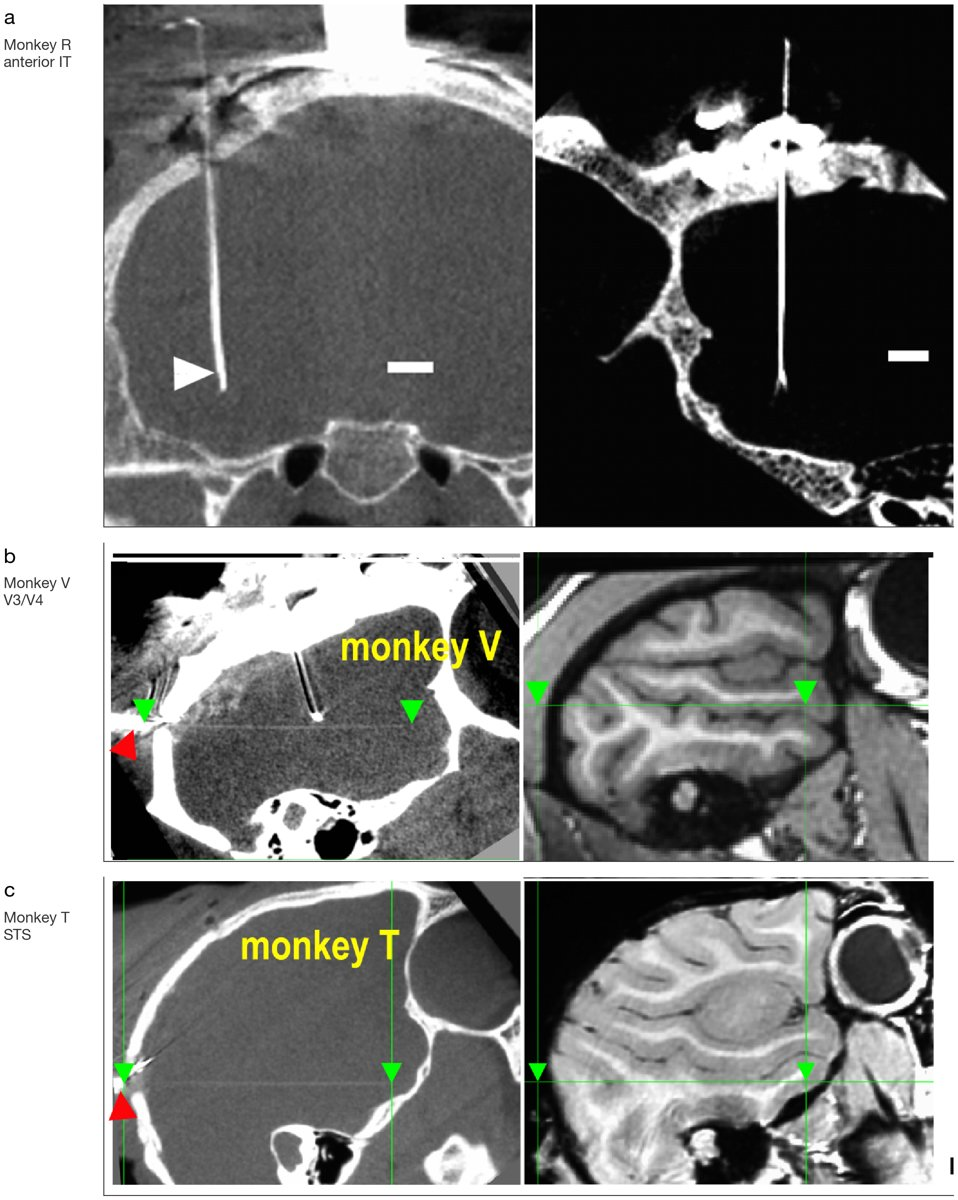

In [10]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# A JPEG preview keeps the notebook small; open the PNG for full detail.
print(png)
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))

**Supplementary Figure S3. Array and Neuropixels probe placement across recorded animals.** Intra-operative CT and structural MRI sections showing probe tracks for the recorded sites. (A) Monkey R, anterior IT: two CT sections; the white arrowhead marks the chronic microwire array tip. (B) Monkey V, V3/V4: CT section (left) and structural MRI (right); green arrowheads mark Neuropixels probe entry and target. (C) Monkey T, STS: same format as (B).